# Informe Técnico — Clasificación Diagnóstica TDAH (13 clases)

| | |
|---|---|
| **Dataset** | `data/processed/processed_data.csv` |
| **N** | 875 pacientes · 14 features · 13 categorías diagnósticas |
| **Modelo** | Random Forest (n=300 árboles, `class_weight='balanced'`) |
| **Validación** | StratifiedKFold k=5 + hold-out test 20% estratificado |
| **Excluidos** | `indice_tdah`, `indice_inatencion`, `indice_impuls_hiperac` (leakage confirmado) |

---


In [32]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (f1_score, accuracy_score, confusion_matrix,
                              classification_report, roc_auc_score)
from sklearn.preprocessing import label_binarize
from sklearn.feature_selection import mutual_info_classif
from sklearn.utils.class_weight import compute_sample_weight
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# ── Paleta ───────────────────────────────────────────────────────────────────
COMB   = '#4C72B0'   # combinado
INAT   = '#55A868'   # inatento
HIPER  = '#DD8452'   # hiperactivo/impulsivo
DESTYP = '#8172B2'   # desarrollo típico
C_TND  = '#C44E52'
C_TEAZ = '#9467BD'
C_TEA  = '#17BECF'
C_GRAY = '#666666'
C_RED  = '#C44E52'
C_ORG  = '#DD8452'
C_BLUE = '#4C72B0'

def subtype_color(lbl):
    l = str(lbl).lower()
    if 'típico' in l or 'tipico' in l: return DESTYP
    if 'combinado'  in l: return COMB
    if 'inatento'   in l: return INAT
    if 'hiperactivo' in l: return HIPER
    return '#999999'

# ── Features ─────────────────────────────────────────────────────────────────
FEATURES = ['edad', 'sexo', 'escolaridad', 'lateralidad',
            'antecedentes_familiares', 'antecedentes_obstetricos', 'retrasos_desarrollo',
            'cit', 'agresividad_basc3', 'hiperactividad_basc3',
            'problemas_conducta_basc3', 'problemas_atencion_basc3',
            'atipicidad_basc3', 'fluidez_fonologica']
FEATURES_CAT = ['sexo', 'lateralidad', 'antecedentes_familiares',
                'antecedentes_obstetricos', 'retrasos_desarrollo']
FEATURE_LABELS = {
    'edad': 'Edad', 'sexo': 'Sexo', 'escolaridad': 'Escolaridad',
    'lateralidad': 'Lateralidad', 'antecedentes_familiares': 'Antec. familiares',
    'antecedentes_obstetricos': 'Antec. obstétricos', 'retrasos_desarrollo': 'Retrasos desarrollo',
    'cit': 'CIT (Wechsler)', 'agresividad_basc3': 'Agresividad (BASC-3)',
    'hiperactividad_basc3': 'Hiperactividad (BASC-3)', 'problemas_conducta_basc3': 'Prob. conducta (BASC-3)',
    'problemas_atencion_basc3': 'Prob. atención (BASC-3)', 'atipicidad_basc3': 'Atipicidad (BASC-3)',
    'fluidez_fonologica': 'Fluidez fonológica',
}
BASC_FEATS = ['agresividad_basc3','hiperactividad_basc3','problemas_conducta_basc3',
              'problemas_atencion_basc3','atipicidad_basc3']

plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'axes.grid': True, 'grid.alpha': 0.35, 'grid.linewidth': 0.6,
})

print("Setup OK.")


Setup OK.


In [33]:
df = pd.read_csv('../data/processed/processed_data.csv', encoding='utf-8-sig')

# Codificación ordinaria de categóricas
X_raw = df[FEATURES].copy()
enc   = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_raw[FEATURES_CAT] = enc.fit_transform(X_raw[FEATURES_CAT])

le = LabelEncoder()
y  = le.fit_transform(df['etiqueta'])
y_labels = le.classes_

print(f"Dataset: {df.shape[0]} registros × {df.shape[1]} columnas")
print(f"Features de entrada: {len(FEATURES)}  |  Clases objetivo: {len(y_labels)}")
print(f"\nResumen de variables numéricas continuas:")
cols_num = ['edad','cit','fluidez_fonologica'] + BASC_FEATS
desc = df[cols_num].describe().loc[['mean','std','min','max']].round(2)
desc.columns = [FEATURE_LABELS[c] for c in desc.columns]
print(desc.T.to_string())


Dataset: 875 registros × 18 columnas
Features de entrada: 14  |  Clases objetivo: 13

Resumen de variables numéricas continuas:
                          mean    std   min    max
Edad                      9.11   2.17   6.0   12.0
CIT (Wechsler)           92.23  15.32  70.0  144.0
Fluidez fonológica       14.68   7.13   0.0   54.0
Agresividad (BASC-3)     56.07  15.86  27.0   99.0
Hiperactividad (BASC-3)  66.13  19.16  27.0   99.0
Prob. conducta (BASC-3)  60.78  17.27  20.0   99.0
Prob. atención (BASC-3)  71.99  16.47  20.0   99.0
Atipicidad (BASC-3)      51.04  14.98  10.0   99.0


## 1 · Variable objetivo

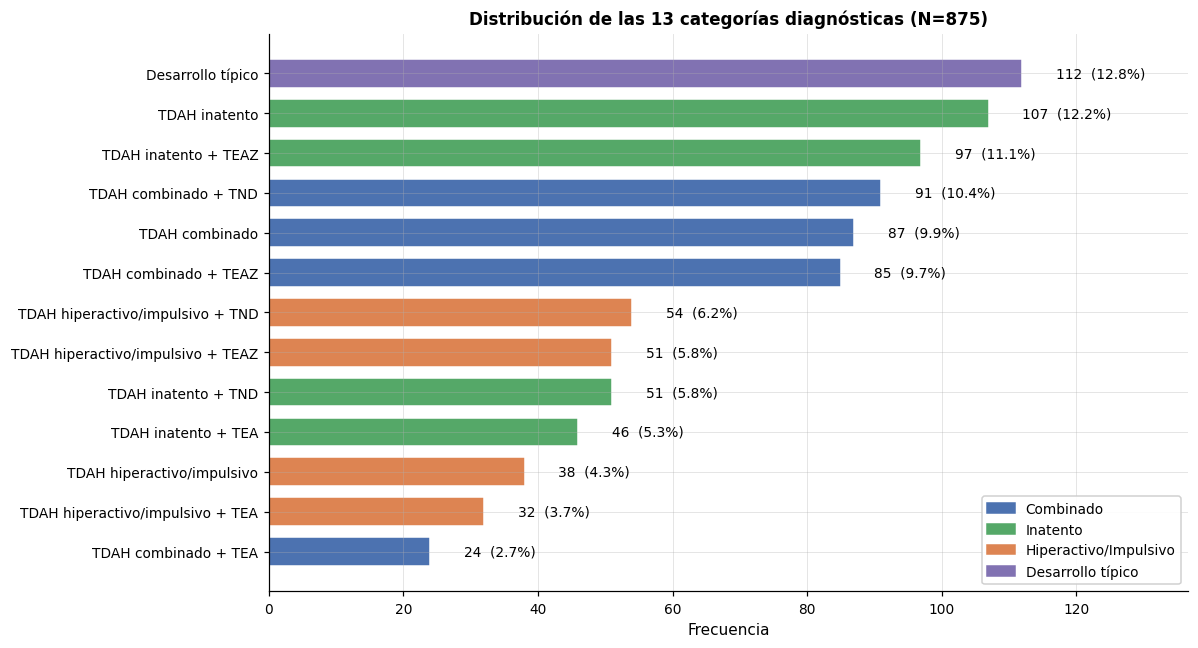


Balance: 4.7× (máx/mín). Clase mínima: TDAH combinado + TEA (n=24)


In [34]:
vc   = df['etiqueta'].value_counts().sort_values()
cols = [subtype_color(l) for l in vc.index]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(vc.index, vc.values, color=cols, edgecolor='white', height=0.72)
for b, v in zip(bars, vc.values):
    ax.text(v + 5, b.get_y() + b.get_height()/2,
            f'{v}  ({v/len(df)*100:.1f}%)', va='center', fontsize=9)
ax.set_xlim(0, vc.max() * 1.22)
ax.set_xlabel('Frecuencia')
ax.set_title('Distribución de las 13 categorías diagnósticas (N=875)', fontweight='bold')
legend_patches = [mpatches.Patch(color=c, label=l) for c, l in
    [(COMB,'Combinado'),(INAT,'Inatento'),(HIPER,'Hiperactivo/Impulsivo'),(DESTYP,'Desarrollo típico')]]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

print(f"\nBalance: {vc.max()/vc.min():.1f}× (máx/mín). Clase mínima: {vc.idxmin()} (n={vc.min()})")


## 2 · Diseño experimental

In [35]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(X_train)} casos  |  Test: {len(X_test)} casos  (80/20 estratificado)")
print(f"CV:    StratifiedKFold k=5, random_state=42")
print(f"\nDistribución por split (top 6 clases):")
for lbl in y_labels:
    idx = le.transform([lbl])[0]
    n_train = (y_train == idx).sum()
    n_test  = (y_test  == idx).sum()
    print(f"  {lbl:<40} train={n_train:>3}  test={n_test:>3}")


Train: 700 casos  |  Test: 175 casos  (80/20 estratificado)
CV:    StratifiedKFold k=5, random_state=42

Distribución por split (top 6 clases):
  Desarrollo típico                        train= 90  test= 22
  TDAH combinado                           train= 69  test= 18
  TDAH combinado + TEA                     train= 19  test=  5
  TDAH combinado + TEAZ                    train= 68  test= 17
  TDAH combinado + TND                     train= 73  test= 18
  TDAH hiperactivo/impulsivo               train= 30  test=  8
  TDAH hiperactivo/impulsivo + TEA         train= 25  test=  7
  TDAH hiperactivo/impulsivo + TEAZ        train= 41  test= 10
  TDAH hiperactivo/impulsivo + TND         train= 43  test= 11
  TDAH inatento                            train= 86  test= 21
  TDAH inatento + TEA                      train= 37  test=  9
  TDAH inatento + TEAZ                     train= 78  test= 19
  TDAH inatento + TND                      train= 41  test= 10


## 3 · Verificación de leakage

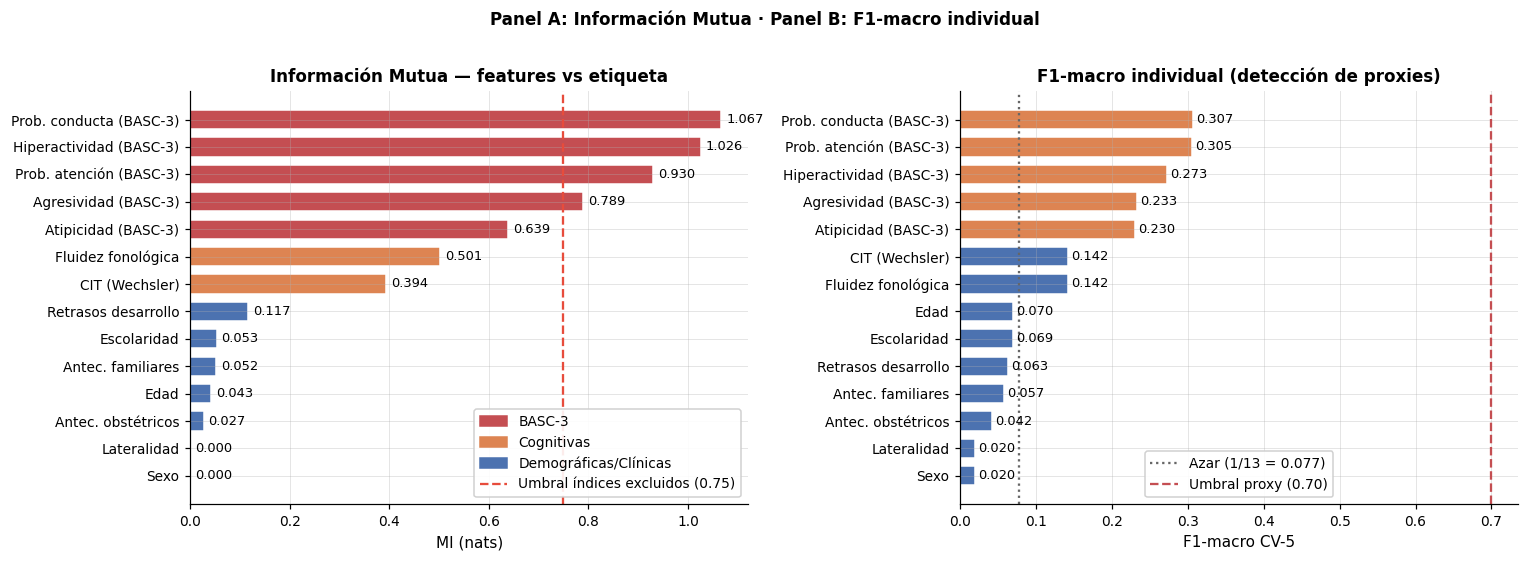


Ningún feature del modelo supera el umbral de proxy (F1 < 0.70).
Los índices TDAH superarían ese umbral si se incluyeran → correctamente excluidos.


In [36]:
mi   = mutual_info_classif(X_raw, y, discrete_features=False, random_state=42)
mi_s = pd.Series(mi, index=FEATURES).sort_values()

# MI de índices excluidos (referencia de leakage)
X_idx = df[['indice_inatencion','indice_impuls_hiperac','indice_tdah']]
mi_idx = mutual_info_classif(X_idx, y, discrete_features=False, random_state=42)
threshold_leakage = mi_idx.min()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─── Panel A: Información mutua ───────────────────────────────────────────────
ax = axes[0]
bar_cols = [C_RED if 'basc3' in f else C_ORG if f in ('cit','fluidez_fonologica') else C_BLUE
            for f in mi_s.index]
bars = ax.barh([FEATURE_LABELS[f] for f in mi_s.index], mi_s.values,
               color=bar_cols, edgecolor='white', height=0.7)
for b, v in zip(bars, mi_s.values):
    ax.text(v + 0.01, b.get_y()+b.get_height()/2, f'{v:.3f}', va='center', fontsize=8.5)
ax.axvline(threshold_leakage, color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'Umbral índices excluidos ({threshold_leakage:.2f})')
ax.set_title('Información Mutua — features vs etiqueta', fontweight='bold')
ax.set_xlabel('MI (nats)')
ax.legend(fontsize=9, framealpha=0.9)
patches = [mpatches.Patch(color=C_RED, label='BASC-3'),
           mpatches.Patch(color=C_ORG, label='Cognitivas'),
           mpatches.Patch(color=C_BLUE, label='Demográficas/Clínicas')]
ax.legend(handles=patches + ax.lines[:1], fontsize=9, framealpha=0.9)

# ─── Panel B: F1-macro individual (proxy test) ────────────────────────────────
rf_q  = RandomForestClassifier(80, class_weight='balanced', random_state=42, n_jobs=-1)
scores_ind = {f: cross_val_score(rf_q, X_raw[[f]], y, cv=CV, scoring='f1_macro').mean()
              for f in FEATURES}
s_df = pd.Series(scores_ind).sort_values()
chance   = 1/len(y_labels)
proxy_t  = 0.70
bar_c2 = [C_RED if v >= proxy_t else C_ORG if v > chance*2 else C_BLUE for v in s_df.values]

ax2 = axes[1]
bars2 = ax2.barh([FEATURE_LABELS[f] for f in s_df.index], s_df.values,
                 color=bar_c2, edgecolor='white', height=0.7)
for b, v in zip(bars2, s_df.values):
    ax2.text(v + 0.004, b.get_y()+b.get_height()/2, f'{v:.3f}', va='center', fontsize=8.5)
ax2.axvline(chance, color=C_GRAY, linestyle=':', linewidth=1.5, label=f'Azar (1/13 = {chance:.3f})')
ax2.axvline(proxy_t, color=C_RED, linestyle='--', linewidth=1.5, label=f'Umbral proxy (0.70)')
ax2.set_title('F1-macro individual (detección de proxies)', fontweight='bold')
ax2.set_xlabel('F1-macro CV-5')
ax2.legend(fontsize=9, framealpha=0.9)

plt.suptitle('Panel A: Información Mutua · Panel B: F1-macro individual',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nNingún feature del modelo supera el umbral de proxy (F1 < 0.70).")
print("Los índices TDAH superarían ese umbral si se incluyeran → correctamente excluidos.")


## 4 · Análisis exploratorio

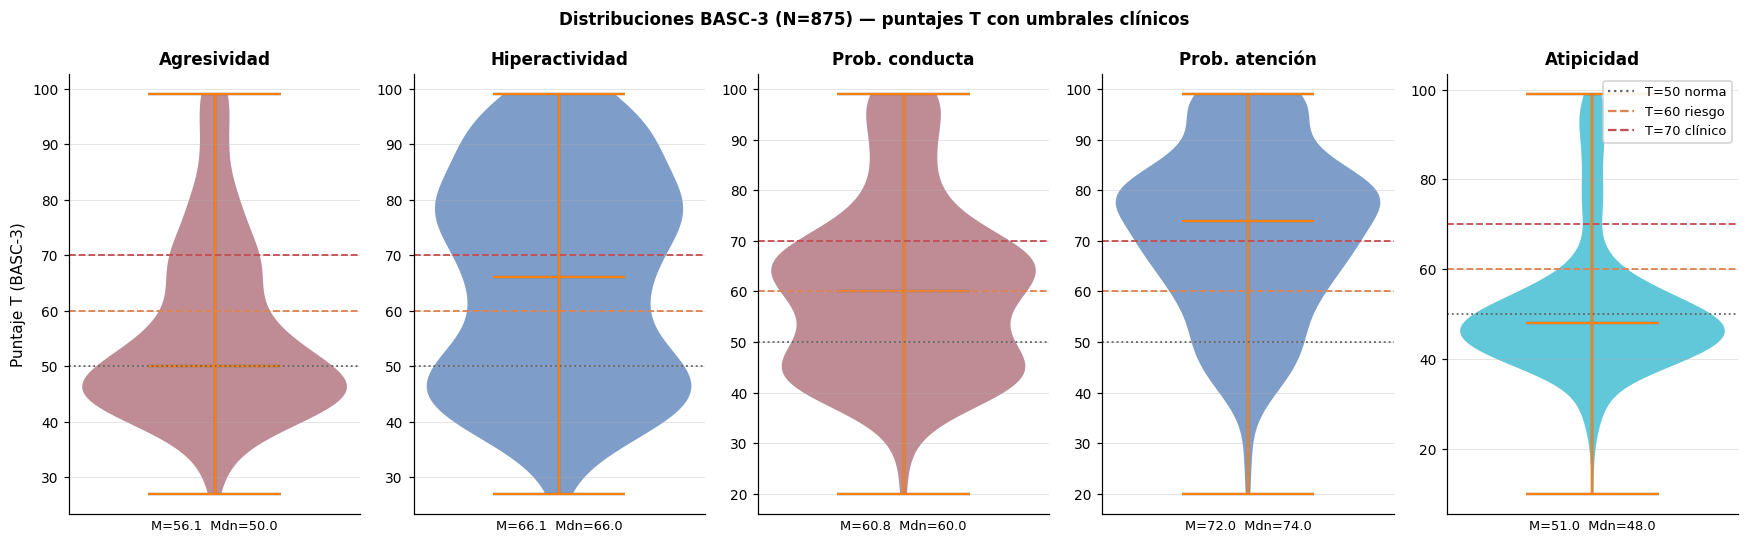

In [37]:
# ── BASC-3: distribuciones por escala (violin + referencia clínica) ───────────
fig, axes = plt.subplots(1, 5, figsize=(16, 5), sharey=False)
basc_labels = {
    'agresividad_basc3': 'Agresividad',  'hiperactividad_basc3': 'Hiperactividad',
    'problemas_conducta_basc3': 'Prob. conducta', 'problemas_atencion_basc3': 'Prob. atención',
    'atipicidad_basc3': 'Atipicidad',
}
colors_basc = [C_TND, C_BLUE, C_TND, C_BLUE, C_TEA]
for ax, (col, lbl), col_v in zip(axes, basc_labels.items(), colors_basc):
    vals = df[col].dropna()
    ax.violinplot(vals, positions=[0], widths=0.7, showmedians=True,
                  bw_method=0.3, points=200)
    vp = ax.violinplot(vals, positions=[0], widths=0.7, showmedians=True, bw_method=0.3)
    for pc in vp['bodies']: pc.set_facecolor(col_v); pc.set_alpha(0.55)
    ax.axhline(50, color=C_GRAY, linestyle=':', linewidth=1.2, label='T=50 (media norma)')
    ax.axhline(60, color=C_ORG,  linestyle='--', linewidth=1.2, label='T=60 (en riesgo)')
    ax.axhline(70, color=C_RED,  linestyle='--', linewidth=1.2, label='T=70 (clínico)')
    ax.set_title(lbl, fontweight='bold')
    ax.set_xticks([])
    m = vals.mean(); med = vals.median()
    ax.set_xlabel(f'M={m:.1f}  Mdn={med:.1f}', fontsize=8.5)

axes[0].set_ylabel('Puntaje T (BASC-3)')
handles = [
    plt.Line2D([0],[0], color=C_GRAY, linestyle=':', label='T=50 norma'),
    plt.Line2D([0],[0], color=C_ORG,  linestyle='--', label='T=60 riesgo'),
    plt.Line2D([0],[0], color=C_RED,  linestyle='--', label='T=70 clínico'),
]
axes[-1].legend(handles=handles, fontsize=8.5, loc='upper right', framealpha=0.9)
plt.suptitle('Distribuciones BASC-3 (N=875) — puntajes T con umbrales clínicos',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()


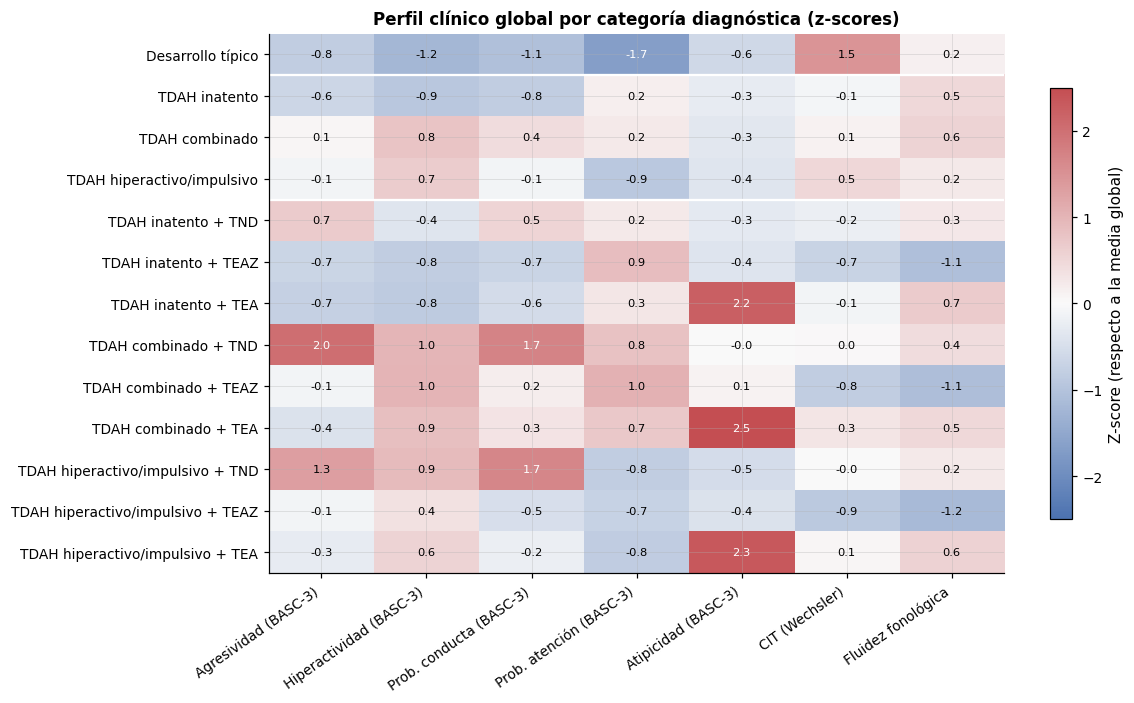

In [38]:
# ── Z-score heatmap por clase diagnóstica ─────────────────────────────────────
vars_num = BASC_FEATS + ['cit', 'fluidez_fonologica']
col_labels = [FEATURE_LABELS[c] for c in vars_num]

means_global = df[vars_num].mean()
stds_global  = df[vars_num].std()
z_matrix = pd.DataFrame({
    lbl: (df[df['etiqueta']==lbl][vars_num].mean() - means_global) / stds_global
    for lbl in y_labels
}, index=vars_num).T

order = ['Desarrollo típico','TDAH inatento','TDAH combinado','TDAH hiperactivo/impulsivo',
         'TDAH inatento + TND','TDAH inatento + TEAZ','TDAH inatento + TEA',
         'TDAH combinado + TND','TDAH combinado + TEAZ','TDAH combinado + TEA',
         'TDAH hiperactivo/impulsivo + TND','TDAH hiperactivo/impulsivo + TEAZ',
         'TDAH hiperactivo/impulsivo + TEA']
z_matrix = z_matrix.reindex([l for l in order if l in z_matrix.index])

fig, ax = plt.subplots(figsize=(11, 6.5))
cmap = LinearSegmentedColormap.from_list('bwr_soft', ['#4C72B0','#FAFAFA','#C44E52'])
im = ax.imshow(z_matrix.values, cmap=cmap, vmin=-2.5, vmax=2.5, aspect='auto')
plt.colorbar(im, ax=ax, label='Z-score (respecto a la media global)', shrink=0.8)
ax.set_xticks(range(len(vars_num))); ax.set_xticklabels(col_labels, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(z_matrix))); ax.set_yticklabels(z_matrix.index, fontsize=9)
for i in range(len(z_matrix)):
    for j in range(len(vars_num)):
        val = z_matrix.values[i,j]
        ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                fontsize=7.5, color='white' if abs(val) > 1.5 else 'black')
ax.axhline(0.5, color='white', linewidth=1.5)   # sep. Desarrollo típico
ax.axhline(3.5, color='white', linewidth=1.5)   # sep. subtipo → con comorbilidad
ax.set_title('Perfil clínico global por categoría diagnóstica (z-scores)', fontweight='bold')
plt.tight_layout()
plt.show()


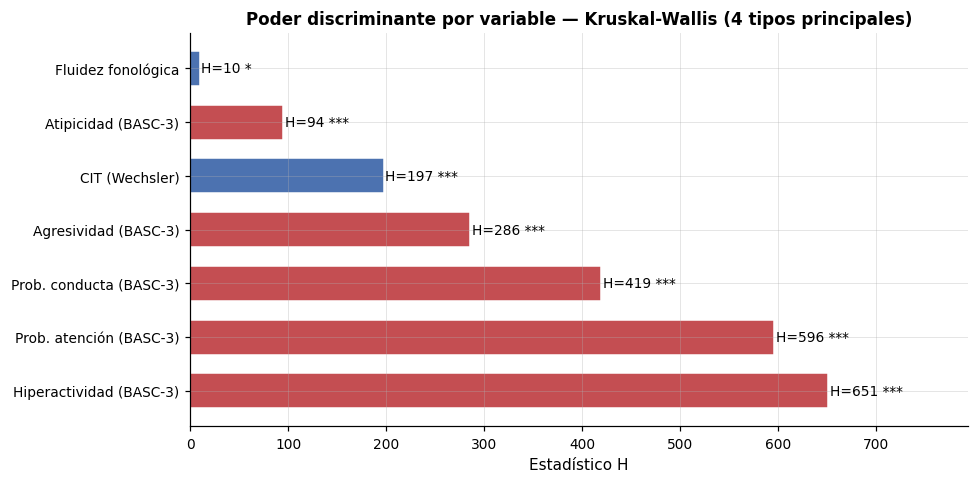


Ranking completo:
                Feature          H p_fmt
Hiperactividad (BASC-3) 650.946203   ***
Prob. atención (BASC-3) 596.321902   ***
Prob. conducta (BASC-3) 419.107315   ***
   Agresividad (BASC-3) 286.035856   ***
         CIT (Wechsler) 197.407784   ***
    Atipicidad (BASC-3)  94.433662   ***
     Fluidez fonológica   9.528547     *


In [39]:
# ── Poder discriminante — Kruskal-Wallis sobre tipo principal ─────────────────
def tipo_principal(e):
    e = str(e).lower()
    if 'típico' in e or 'tipico' in e: return 'Desarrollo típico'
    if 'inatento' in e: return 'Inatento'
    if 'combinado' in e: return 'Combinado'
    if 'hiperactivo' in e: return 'Hiperactivo/Impuls.'
    return 'Otro'

df['tipo_tdah'] = df['etiqueta'].apply(tipo_principal)

cols_disc = vars_num
kw_rows = []
for col in cols_disc:
    grupos = [g[col].values for _, g in df.groupby('tipo_tdah')]
    H, p = stats.kruskal(*grupos)
    kw_rows.append({'Feature': FEATURE_LABELS[col], 'H': H, 'p': p,
                    'p_fmt': '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'})
kw_df = pd.DataFrame(kw_rows).sort_values('H', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors_kw = [C_RED if any(b in row['Feature'].lower() for b in ['agresiv','atipic','hiperactividad','conducta','atenc'])
             else C_BLUE for _, row in kw_df.iterrows()]
bars = ax.barh(kw_df['Feature'], kw_df['H'], color=colors_kw, edgecolor='white', height=0.65)
for b, (_, row) in zip(bars, kw_df.iterrows()):
    ax.text(b.get_width() + 2, b.get_y()+b.get_height()/2,
            f"H={row['H']:.0f} {row['p_fmt']}", va='center', fontsize=9)
ax.set_title('Poder discriminante por variable — Kruskal-Wallis (4 tipos principales)',
             fontweight='bold')
ax.set_xlabel('Estadístico H')
ax.set_xlim(0, kw_df['H'].max() * 1.22)
plt.tight_layout()
plt.show()

print("\nRanking completo:")
print(kw_df[['Feature','H','p_fmt']].to_string(index=False))


## 5 · Análisis de comorbilidades

Muestra TDAH: 763 casos (excluye Desarrollo típico)
  TND  : 196 (25.7%)
  TEAZ : 233 (30.5%)
  TEA  : 102 (13.4%)
  Sin comorbilidad: 232


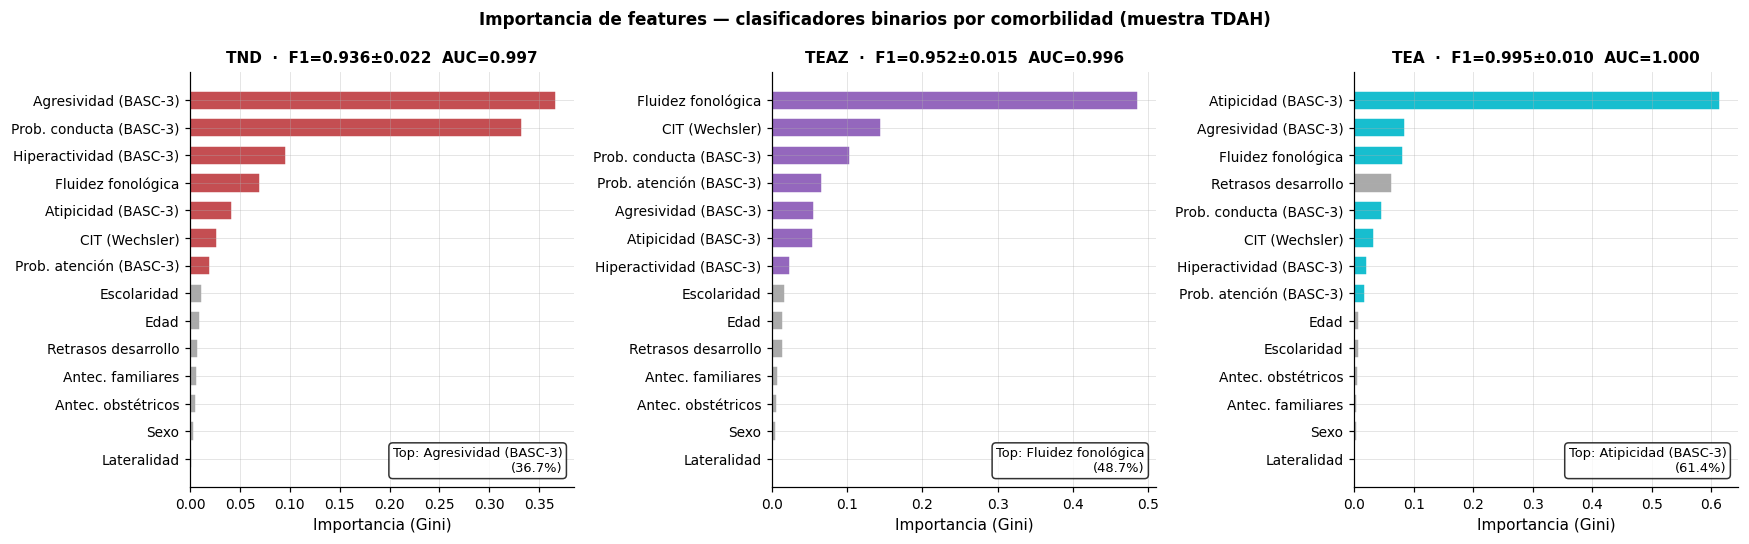

In [40]:
# ── Prevalencia de comorbilidades en la muestra TDAH ─────────────────────────
df_tdah = df[df['tipo_tdah'] != 'Desarrollo típico'].copy()
df_tdah['has_tnd']  = df_tdah['etiqueta'].str.lower().str.contains('tnd')
df_tdah['has_teaz'] = df_tdah['etiqueta'].str.lower().str.contains('teaz')
df_tdah['has_tea']  = df_tdah['etiqueta'].str.lower().str.contains(r'\btea\b')
n_tdah = len(df_tdah)

print(f"Muestra TDAH: {n_tdah} casos (excluye Desarrollo típico)")
print(f"  TND  : {df_tdah['has_tnd'].sum():>3} ({df_tdah['has_tnd'].mean()*100:.1f}%)")
print(f"  TEAZ : {df_tdah['has_teaz'].sum():>3} ({df_tdah['has_teaz'].mean()*100:.1f}%)")
print(f"  TEA  : {df_tdah['has_tea'].sum():>3} ({df_tdah['has_tea'].mean()*100:.1f}%)")
print(f"  Sin comorbilidad: {(~(df_tdah['has_tnd']|df_tdah['has_teaz']|df_tdah['has_tea'])).sum()}")

# ── Clasificadores binarios por comorbilidad ──────────────────────────────────
X_tdah = df_tdah[FEATURES].copy()
enc2   = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_tdah[FEATURES_CAT] = enc2.fit_transform(X_tdah[FEATURES_CAT])

def binary_clf(flag_col, label, color):
    y_bin = df_tdah[flag_col].astype(int).values
    rf_b  = RandomForestClassifier(300, class_weight='balanced', random_state=42, n_jobs=-1)
    cv_res = cross_validate(rf_b, X_tdah, y_bin, cv=CV,
                            scoring=['f1','roc_auc'], return_train_score=False)
    rf_b.fit(X_tdah, y_bin)
    imp  = pd.Series(rf_b.feature_importances_, index=FEATURES)
    top1 = FEATURE_LABELS[imp.idxmax()]
    basc_imp = imp[BASC_FEATS].sum()
    return {
        'label': label, 'color': color,
        'f1':  cv_res['test_f1'].mean(),   'f1_std':  cv_res['test_f1'].std(),
        'auc': cv_res['test_roc_auc'].mean(), 'auc_std': cv_res['test_roc_auc'].std(),
        'top_feat': top1,  'top_imp': imp.max(),
        'basc_imp': basc_imp, 'importances': imp,
    }

res_comorb = {
    'TND':  binary_clf('has_tnd',  'TND',  C_TND),
    'TEAZ': binary_clf('has_teaz', 'TEAZ', C_TEAZ),
    'TEA':  binary_clf('has_tea',  'TEA',  C_TEA),
}

# ── Gráfica: importancia de features por comorbilidad ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (key, r) in zip(axes, res_comorb.items()):
    imp_s = r['importances'].sort_values()
    bar_cols = [r['color'] if 'basc3' in f or f in ('cit','fluidez_fonologica')
                else '#AAAAAA' for f in imp_s.index]
    ax.barh([FEATURE_LABELS[f] for f in imp_s.index], imp_s.values,
            color=bar_cols, edgecolor='white', height=0.7)
    ax.set_title(f'{key}  ·  F1={r["f1"]:.3f}±{r["f1_std"]:.3f}  AUC={r["auc"]:.3f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Importancia (Gini)')
    ax.text(0.97, 0.03, f'Top: {r["top_feat"]}\n({r["top_imp"]*100:.1f}%)',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.suptitle('Importancia de features — clasificadores binarios por comorbilidad (muestra TDAH)',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()


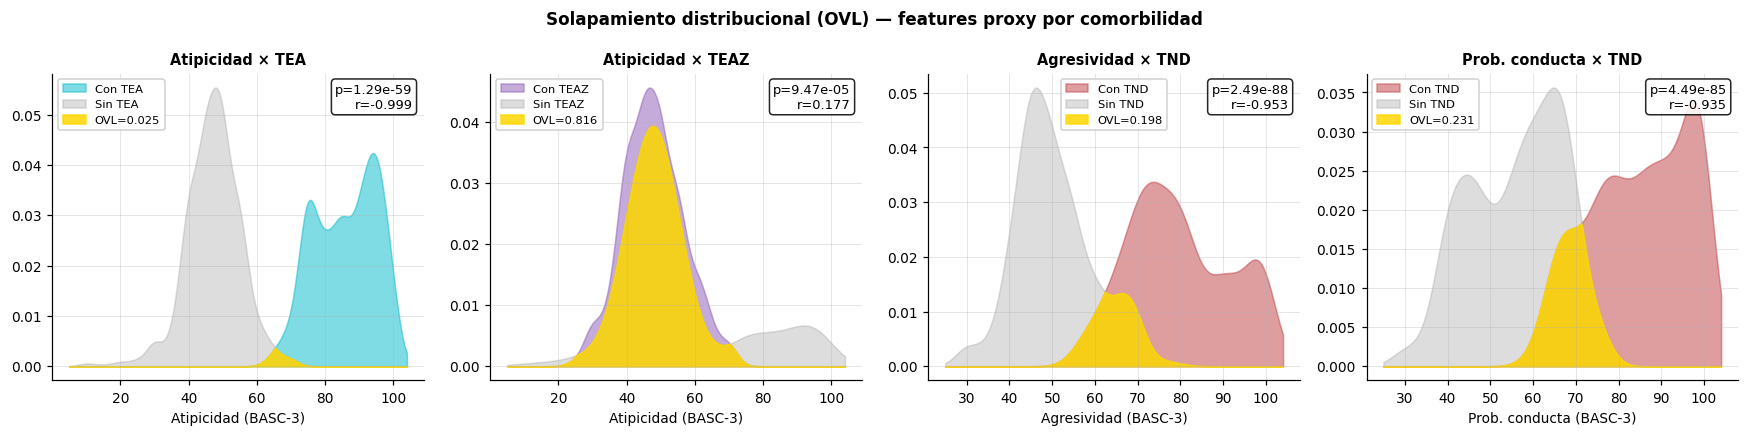

In [41]:
# ── Coeficiente de solapamiento (OVL) ────────────────────────────────────────
def overlap_coeff(a, b, n_points=500):
    lo, hi = min(a.min(),b.min())-5, max(a.max(),b.max())+5
    xs = np.linspace(lo, hi, n_points)
    ka = gaussian_kde(a, bw_method=0.3)(xs)
    kb = gaussian_kde(b, bw_method=0.3)(xs)
    return float(np.trapezoid(np.minimum(ka,kb), xs))

comparisons = [
    ('atipicidad_basc3',        'has_tea',  'TEA',  C_TEA,  'Atipicidad × TEA'),
    ('atipicidad_basc3',        'has_teaz', 'TEAZ', C_TEAZ, 'Atipicidad × TEAZ'),
    ('agresividad_basc3',       'has_tnd',  'TND',  C_TND,  'Agresividad × TND'),
    ('problemas_conducta_basc3','has_tnd',  'TND',  C_TND,  'Prob. conducta × TND'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (feat, flag, comorb_name, color, title) in zip(axes, comparisons):
    pos_vals = df_tdah[df_tdah[flag]][feat].values
    neg_vals = df_tdah[~df_tdah[flag]][feat].values
    stat, p   = stats.mannwhitneyu(pos_vals, neg_vals, alternative='two-sided')
    r_rb = 1 - 2*stat / (len(pos_vals)*len(neg_vals))
    ovl  = overlap_coeff(pos_vals, neg_vals)
    lo, hi = min(pos_vals.min(),neg_vals.min())-5, max(pos_vals.max(),neg_vals.max())+5
    xs = np.linspace(lo, hi, 300)
    k_pos = gaussian_kde(pos_vals, bw_method=0.3)(xs)
    k_neg = gaussian_kde(neg_vals, bw_method=0.3)(xs)
    ax.fill_between(xs, k_pos, alpha=0.55, color=color, label=f'Con {comorb_name}')
    ax.fill_between(xs, k_neg, alpha=0.4, color='#AAAAAA', label=f'Sin {comorb_name}')
    ax.fill_between(xs, np.minimum(k_pos,k_neg), alpha=0.85, color='#FFD700', label=f'OVL={ovl:.3f}')
    ax.set_title(title, fontweight='bold', fontsize=9.5)
    ax.set_xlabel(FEATURE_LABELS[feat], fontsize=9)
    ax.legend(fontsize=7.5, framealpha=0.9)
    ax.text(0.97, 0.97, f'p={p:.2e}\nr={r_rb:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

plt.suptitle('Solapamiento distribucional (OVL) — features proxy por comorbilidad',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()


In [42]:
# ── Tabla síntesis comorbilidades ─────────────────────────────────────────────
rows = []
for comorb, flag in [('TND','has_tnd'),('TEAZ','has_teaz'),('TEA','has_tea')]:
    for feat in BASC_FEATS[:2] if comorb=='TND' else ['atipicidad_basc3']:
        pos = df_tdah[df_tdah[flag]][feat].values
        neg = df_tdah[~df_tdah[flag]][feat].values
        stat, p = stats.mannwhitneyu(pos, neg, alternative='two-sided')
        r_rb = 1 - 2*stat/(len(pos)*len(neg))
        ovl  = overlap_coeff(pos, neg)
        rows.append({
            'Comorbilidad': comorb, 'Feature': FEATURE_LABELS[feat],
            'n_pos': len(pos), 'M_pos': pos.mean().round(1), 'M_neg': neg.mean().round(1),
            'p': p, 'r': r_rb.round(3), 'OVL': round(ovl,3),
            'Interpretación': ('Buen discriminante' if ovl<0.3 else
                               'Discriminación moderada' if ovl<0.6 else
                               'Poca separabilidad'),
        })

synth = pd.DataFrame(rows)
print(synth.to_string(index=False))


Comorbilidad                 Feature  n_pos  M_pos  M_neg            p      r   OVL     Interpretación
         TND    Agresividad (BASC-3)    196   79.6   50.5 2.493558e-88 -0.953 0.198 Buen discriminante
         TND Hiperactividad (BASC-3)    196   77.8   66.7 9.078127e-14 -0.357 0.679 Poca separabilidad
        TEAZ     Atipicidad (BASC-3)    233   47.8   54.4 9.471169e-05  0.177 0.816 Poca separabilidad
         TEA     Atipicidad (BASC-3)    102   85.9   47.2 1.289116e-59 -0.999 0.025 Buen discriminante


## 6 · Modelado con validación cruzada

In [43]:
# ── Tres modelos + CV ─────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

models = {
    'Reg. Logística': LogisticRegression(class_weight='balanced', max_iter=1000,
                                          random_state=42, n_jobs=-1),
    'Random Forest':  RandomForestClassifier(n_estimators=300, max_depth=None,
                                              min_samples_leaf=2, class_weight='balanced',
                                              random_state=42, n_jobs=-1),
    'XGBoost':        XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                    subsample=0.8, colsample_bytree=0.8, use_label_encoder=False,
                                    eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0),
}

results = {}
for name, mdl in models.items():
    kw = {'sample_weight': compute_sample_weight('balanced', y_train)} if 'XGBoost' in name else {}
    cv_res = cross_validate(mdl, X_train, y_train, cv=CV,
                            scoring=['f1_macro','accuracy'], return_train_score=False)
    if 'XGBoost' in name:
        mdl.fit(X_train, y_train, **kw)
    else:
        mdl.fit(X_train, y_train)
    y_pred = mdl.predict(X_test)
    results[name] = {
        'cv_f1': cv_res['test_f1_macro'], 'cv_acc': cv_res['test_accuracy'],
        'test_f1': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'test_acc': accuracy_score(y_test, y_pred),
        'y_pred': y_pred,
        'y_proba': mdl.predict_proba(X_test),
        'model': mdl,
    }
    print(f"{name:<22}  CV F1={cv_res['test_f1_macro'].mean():.3f}±{cv_res['test_f1_macro'].std():.3f}"
          f"  Test F1={results[name]['test_f1']:.3f}  Acc={results[name]['test_acc']:.3f}")


Reg. Logística          CV F1=0.843±0.024  Test F1=0.851  Acc=0.874
Random Forest           CV F1=0.954±0.016  Test F1=0.943  Acc=0.949
XGBoost                 CV F1=0.929±0.020  Test F1=0.945  Acc=0.949


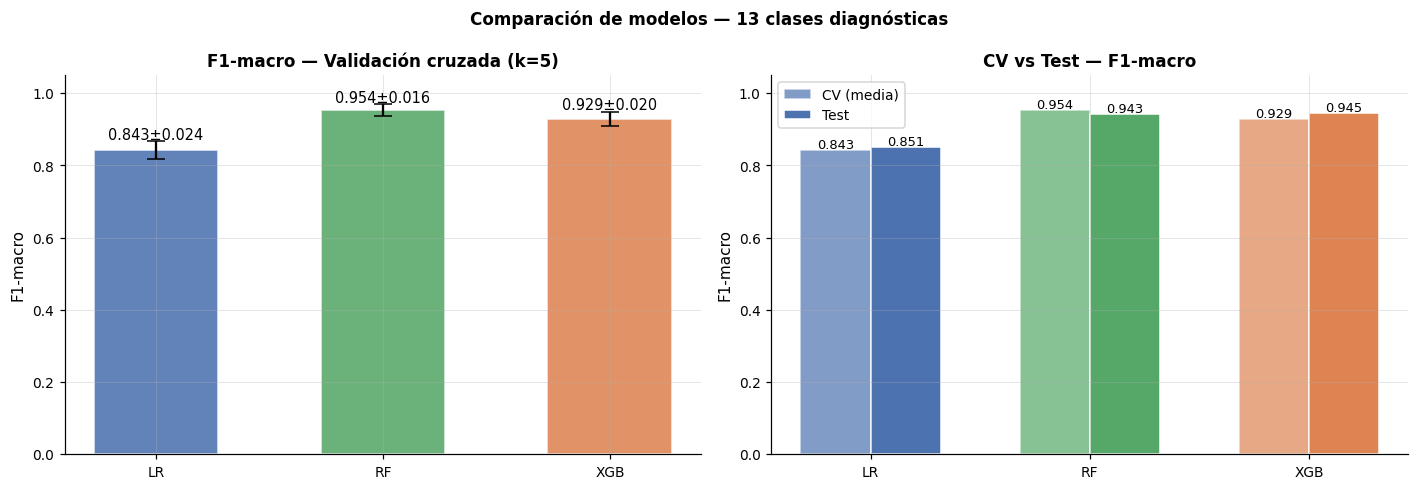


Mejor modelo: XGBoost  →  Test F1-macro = 0.9448


In [44]:
# ── Gráfica comparativa de modelos ────────────────────────────────────────────
names_short = ['LR', 'RF', 'XGB']
names_full  = list(results.keys())
cv_means  = [results[n]['cv_f1'].mean() for n in names_full]
cv_stds   = [results[n]['cv_f1'].std()  for n in names_full]
test_f1s  = [results[n]['test_f1']      for n in names_full]
bar_colors = ['#4C72B0','#55A868','#DD8452']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel A: CV F1 con barras de error
ax = axes[0]
bars = ax.bar(names_short, cv_means, yerr=cv_stds, color=bar_colors,
              edgecolor='white', capsize=6, alpha=0.88, width=0.55)
for b, v, s in zip(bars, cv_means, cv_stds):
    ax.text(b.get_x()+b.get_width()/2, v + s + 0.005,
            f'{v:.3f}±{s:.3f}', ha='center', fontsize=9.5)
ax.set_ylim(0, 1.05)
ax.set_title('F1-macro — Validación cruzada (k=5)', fontweight='bold')
ax.set_ylabel('F1-macro')

# Panel B: CV vs Test F1 side-by-side
x = np.arange(len(names_short))
w = 0.32
ax2 = axes[1]
b1 = ax2.bar(x - w/2, cv_means, w, label='CV (media)', color=bar_colors, alpha=0.7, edgecolor='white')
b2 = ax2.bar(x + w/2, test_f1s, w, label='Test',       color=bar_colors, alpha=1.0, edgecolor='white')
for xi, (cv_v, te_v) in enumerate(zip(cv_means, test_f1s)):
    ax2.text(xi - w/2, cv_v + 0.005, f'{cv_v:.3f}', ha='center', fontsize=8.5)
    ax2.text(xi + w/2, te_v + 0.005, f'{te_v:.3f}', ha='center', fontsize=8.5)
ax2.set_xticks(x); ax2.set_xticklabels(names_short)
ax2.set_ylim(0, 1.05)
ax2.set_title('CV vs Test — F1-macro', fontweight='bold')
ax2.set_ylabel('F1-macro')
ax2.legend(fontsize=9)

plt.suptitle('Comparación de modelos — 13 clases diagnósticas', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

best_name = max(results, key=lambda n: results[n]['test_f1'])
best = results[best_name]
print(f"\nMejor modelo: {best_name}  →  Test F1-macro = {best['test_f1']:.4f}")


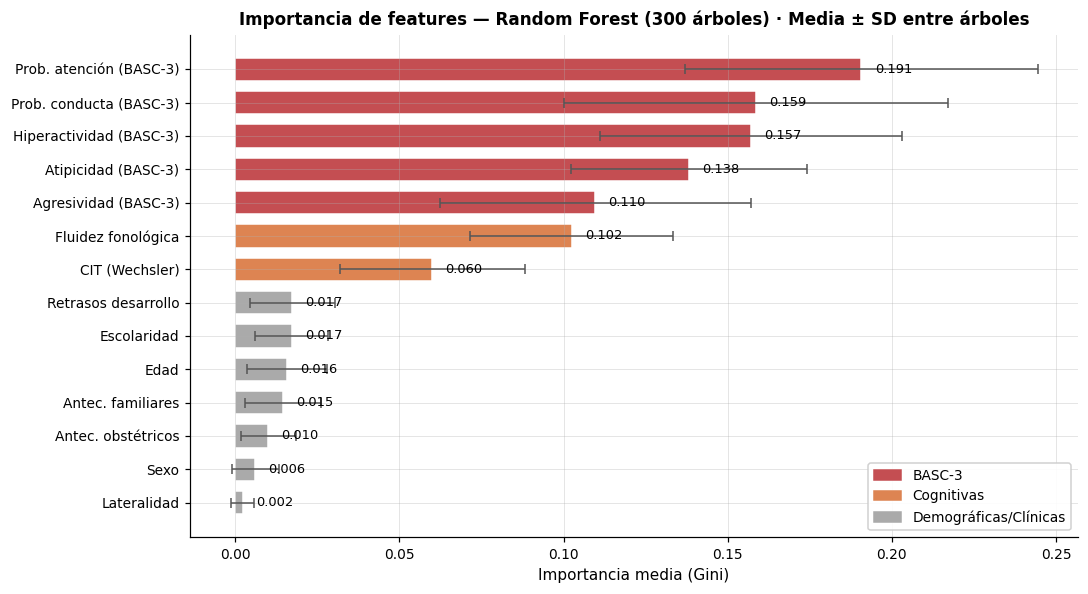


Importancia acumulada BASC-3: 75.4%
Feature más importante: 'Prob. atención (BASC-3)' → 19.1%


In [45]:
# ── Feature importance — Random Forest ───────────────────────────────────────
rf_model = results['Random Forest']['model']
imp_mean = rf_model.feature_importances_
imp_std  = np.std([t.feature_importances_ for t in rf_model.estimators_], axis=0)
imp_s    = pd.Series(imp_mean, index=FEATURES).sort_values()
imp_err  = pd.Series(imp_std, index=FEATURES).reindex(imp_s.index)

fig, ax = plt.subplots(figsize=(10, 5.5))
bar_c = [C_RED if 'basc3' in f else C_ORG if f in ('cit','fluidez_fonologica') else '#AAAAAA'
         for f in imp_s.index]
bars = ax.barh([FEATURE_LABELS[f] for f in imp_s.index], imp_s.values,
               xerr=imp_err.values, error_kw=dict(elinewidth=1, capsize=3, ecolor='#555'),
               color=bar_c, edgecolor='white', height=0.7)
for b, v in zip(bars, imp_s.values):
    ax.text(v + imp_err.iloc[list(imp_s.index).index(b.get_label() if hasattr(b,'get_label') else '')] + 0.002
            if False else v + 0.004,
            b.get_y()+b.get_height()/2, f'{v:.3f}', va='center', fontsize=8.5)
patches = [mpatches.Patch(color=C_RED, label='BASC-3'),
           mpatches.Patch(color=C_ORG, label='Cognitivas'),
           mpatches.Patch(color='#AAAAAA', label='Demográficas/Clínicas')]
ax.legend(handles=patches, fontsize=9, framealpha=0.9)
ax.set_title('Importancia de features — Random Forest (300 árboles) · Media ± SD entre árboles',
             fontweight='bold')
ax.set_xlabel('Importancia media (Gini)')
plt.tight_layout()
plt.show()

basc_total = imp_s[BASC_FEATS].sum()
print(f"\nImportancia acumulada BASC-3: {basc_total*100:.1f}%")
print(f"Feature más importante: '{FEATURE_LABELS[imp_s.idxmax()]}' → {imp_s.max()*100:.1f}%")


## 7 · Reporte de métricas

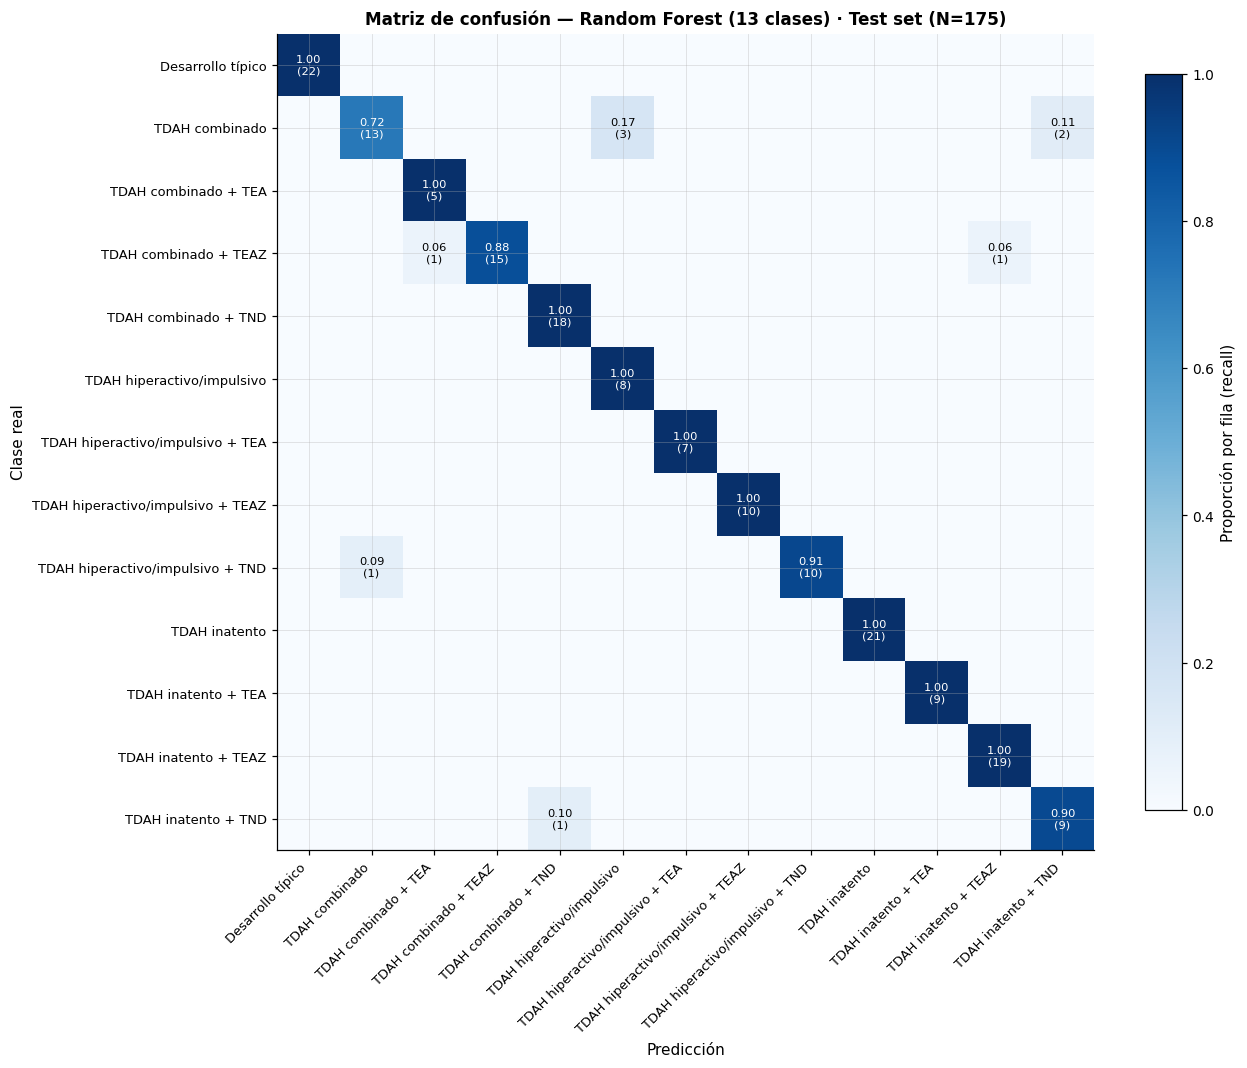


Errores totales: 9/175 (5.1%)
F1-macro test: 0.9429


In [46]:
# ── Matriz de confusión — Random Forest ──────────────────────────────────────
y_pred_rf = results['Random Forest']['y_pred']
cm  = confusion_matrix(y_test, y_pred_rf)
cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Proporción por fila (recall)', shrink=0.85)
ticks = range(len(y_labels))
ax.set_xticks(ticks); ax.set_xticklabels(y_labels, rotation=45, ha='right', fontsize=8.5)
ax.set_yticks(ticks); ax.set_yticklabels(y_labels, fontsize=8.5)
for i in range(len(y_labels)):
    for j in range(len(y_labels)):
        v = cmn[i,j]; n = cm[i,j]
        if n > 0:
            ax.text(j, i, f'{v:.2f}\n({n})', ha='center', va='center',
                    fontsize=7.5, color='white' if v > 0.55 else 'black')
ax.set_xlabel('Predicción'); ax.set_ylabel('Clase real')
ax.set_title('Matriz de confusión — Random Forest (13 clases) · Test set (N=175)',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

total_errors = (y_test != y_pred_rf).sum()
print(f"\nErrores totales: {total_errors}/{len(y_test)} ({total_errors/len(y_test)*100:.1f}%)")
print(f"F1-macro test: {results['Random Forest']['test_f1']:.4f}")


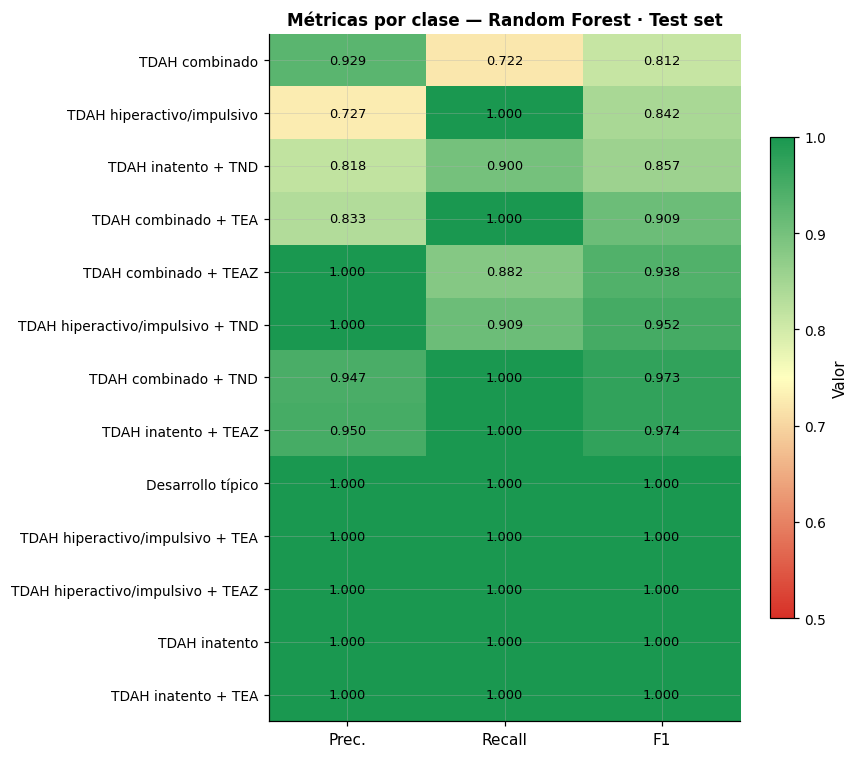


Clases con F1 < 0.90:
                     Clase    F1  Support
            TDAH combinado 0.812       18
TDAH hiperactivo/impulsivo 0.842        8
       TDAH inatento + TND 0.857       10


In [47]:
# ── Reporte por clase ─────────────────────────────────────────────────────────
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1c, sup = precision_recall_fscore_support(y_test, y_pred_rf, zero_division=0)
rep_df = pd.DataFrame({
    'Clase': y_labels, 'Prec.': prec.round(3), 'Recall': rec.round(3),
    'F1': f1c.round(3), 'Support': sup,
}).sort_values('F1')

# Visual: heatmap de métricas por clase
fig, ax = plt.subplots(figsize=(8, 7))
data_heat = rep_df[['Prec.','Recall','F1']].values
cmap_m = LinearSegmentedColormap.from_list('grn', ['#d73027','#ffffbf','#1a9850'])
im = ax.imshow(data_heat, cmap=cmap_m, vmin=0.5, vmax=1.0, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.7, label='Valor')
ax.set_xticks([0,1,2]); ax.set_xticklabels(['Prec.','Recall','F1'], fontsize=10)
ax.set_yticks(range(len(rep_df))); ax.set_yticklabels(rep_df['Clase'], fontsize=9)
for i in range(len(rep_df)):
    for j, col in enumerate(['Prec.','Recall','F1']):
        v = rep_df.iloc[i][col]
        ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                fontsize=8.5, color='white' if v < 0.7 else 'black')
ax.set_title('Métricas por clase — Random Forest · Test set', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nClases con F1 < 0.90:")
low = rep_df[rep_df['F1'] < 0.90]
if len(low): print(low[['Clase','F1','Support']].to_string(index=False))
else: print("  Ninguna — todas las clases ≥ 0.90")


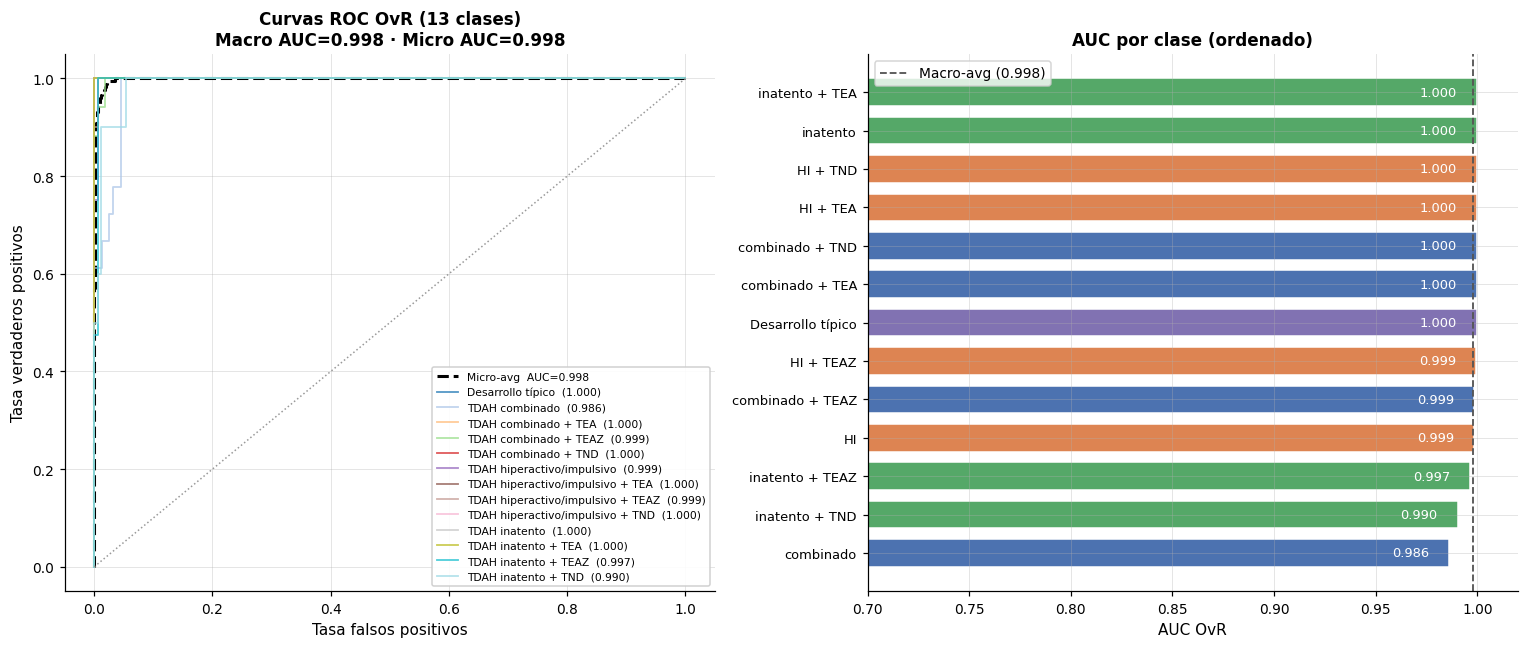

Macro-avg AUC: 0.9977  |  Micro-avg AUC: 0.9984


In [48]:
# ── Curvas ROC One-vs-Rest — Random Forest ────────────────────────────────────
from sklearn.metrics import roc_curve, auc as sk_auc

y_proba_rf = results['Random Forest']['y_proba']
n   = len(y_labels)
y_bin = label_binarize(y_test, classes=range(n))
palette = plt.cm.get_cmap('tab20', n)

# Calcular AUC por clase
auc_vals, fprs, tprs = [], [], []
for i in range(n):
    fpr, tpr, _ = roc_curve(y_bin[:,i], y_proba_rf[:,i])
    a = sk_auc(fpr, tpr)
    auc_vals.append(a); fprs.append(fpr); tprs.append(tpr)

fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), y_proba_rf.ravel())
roc_micro  = sk_auc(fpr_micro, tpr_micro)
macro_auc  = np.mean(auc_vals)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: todas las curvas
ax = axes[0]
ax.plot(fpr_micro, tpr_micro, 'k--', lw=2, label=f'Micro-avg  AUC={roc_micro:.3f}')
for i, lbl in enumerate(y_labels):
    ax.plot(fprs[i], tprs[i], color=palette(i), lw=1.2, alpha=0.75,
            label=f'{lbl}  ({auc_vals[i]:.3f})')
ax.plot([0,1],[0,1],':', color='#999', lw=1)
ax.set_xlabel('Tasa falsos positivos'); ax.set_ylabel('Tasa verdaderos positivos')
ax.set_title(f'Curvas ROC OvR (13 clases)\nMacro AUC={macro_auc:.3f} · Micro AUC={roc_micro:.3f}',
             fontweight='bold')
ax.legend(fontsize=7, framealpha=0.9, loc='lower right', ncol=1)

# Panel B: AUC por clase (bar chart)
ax2 = axes[1]
sort_idx = np.argsort(auc_vals)
short_lbls = [y_labels[i].replace('TDAH ','').replace('hiperactivo/impulsivo','HI') for i in sort_idx]
bar_c = [subtype_color(y_labels[i]) for i in sort_idx]
bars = ax2.barh(range(n), [auc_vals[i] for i in sort_idx], color=bar_c,
                edgecolor='white', height=0.72)
for b, i in zip(bars, sort_idx):
    ax2.text(b.get_width()-0.01, b.get_y()+b.get_height()/2,
             f'{auc_vals[i]:.3f}', va='center', ha='right', fontsize=8.5,
             color='white' if auc_vals[i] > 0.97 else 'black')
ax2.axvline(macro_auc, color='#555', linestyle='--', lw=1.2,
            label=f'Macro-avg ({macro_auc:.3f})')
ax2.set_yticks(range(n)); ax2.set_yticklabels(short_lbls, fontsize=8.5)
ax2.set_xlim(0.7, 1.02); ax2.set_xlabel('AUC OvR')
ax2.set_title('AUC por clase (ordenado)', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()
print(f"Macro-avg AUC: {macro_auc:.4f}  |  Micro-avg AUC: {roc_micro:.4f}")


## 8 · Análisis de errores

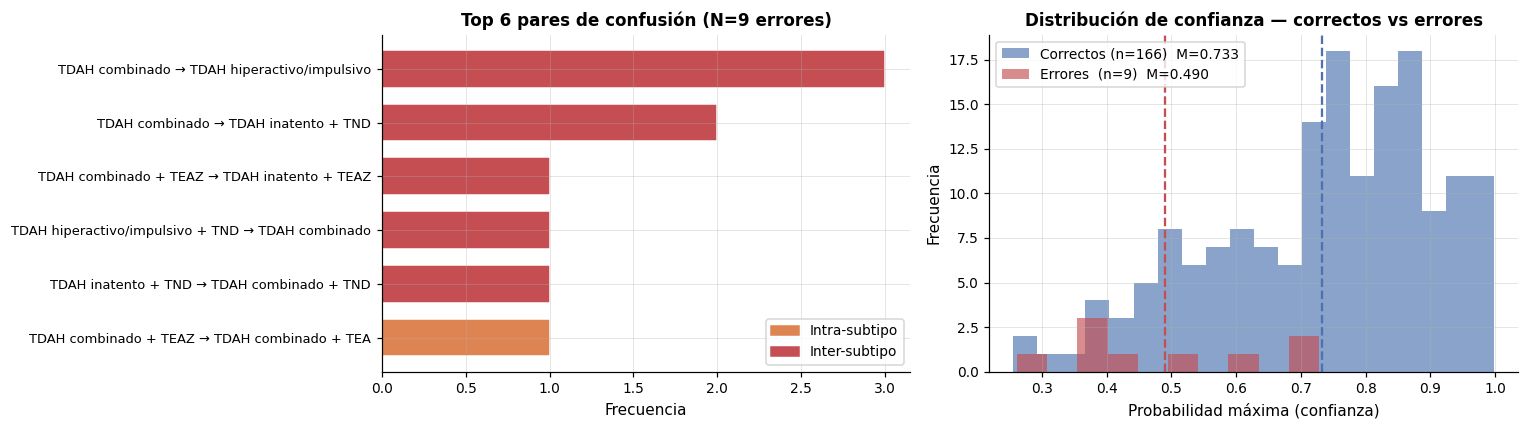

Errores intra-subtipo (comorbilidad equivocada): 1
Errores inter-subtipo (subtipo TDAH equivocado): 5

Confianza media — correctos: 0.733  |  errores: 0.490


In [49]:
# ── Pares de confusión más frecuentes ────────────────────────────────────────
mask_err = y_test != y_pred_rf
y_err_true = le.inverse_transform(y_test[mask_err])
y_err_pred = le.inverse_transform(y_pred_rf[mask_err])

pairs = pd.Series([f'{t} → {p}' for t, p in zip(y_err_true, y_err_pred)]).value_counts()

# Clasificar cada par: intra-subtipo vs inter-subtipo
def tipo_base(lbl):
    l = str(lbl).lower()
    if 'típico' in l or 'tipico' in l: return 'típico'
    if 'inatento' in l: return 'inatento'
    if 'combinado' in l: return 'combinado'
    if 'hiperactivo' in l: return 'hiperactivo'
    return '?'

pair_types = []
for pair_str in pairs.index:
    true_p, pred_p = pair_str.split(' → ')
    t1, t2 = tipo_base(true_p), tipo_base(pred_p)
    pair_types.append('Intra-subtipo' if t1==t2 else 'Inter-subtipo')

top_n = min(12, len(pairs))
fig, axes = plt.subplots(1, 2, figsize=(14, max(4, top_n*0.48+1)))

# Panel A: pares
ax = axes[0]
top_pairs = pairs.head(top_n)
colors_pair = [C_ORG if pt=='Intra-subtipo' else C_RED
               for pt in pair_types[:top_n]]
ax.barh(range(top_n), top_pairs.values[::-1], color=colors_pair[::-1],
        edgecolor='white', height=0.7)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_pairs.index[::-1], fontsize=8.5)
ax.set_xlabel('Frecuencia')
ax.set_title(f'Top {top_n} pares de confusión (N={mask_err.sum()} errores)',
             fontweight='bold')
patches_p = [mpatches.Patch(color=C_ORG, label='Intra-subtipo'),
             mpatches.Patch(color=C_RED,  label='Inter-subtipo')]
ax.legend(handles=patches_p, fontsize=9)

# Panel B: confianza correctos vs errores
y_proba_max = y_proba_rf.max(axis=1)
ax2 = axes[1]
v_ok  = y_proba_max[~mask_err]
v_err = y_proba_max[mask_err]
ax2.hist(v_ok,  bins=20, alpha=0.65, color=C_BLUE, label=f'Correctos (n={len(v_ok)})  M={v_ok.mean():.3f}')
ax2.hist(v_err, bins=10, alpha=0.65, color=C_RED,  label=f'Errores  (n={len(v_err)})  M={v_err.mean():.3f}')
ax2.axvline(v_ok.mean(),  color=C_BLUE, linestyle='--', linewidth=1.5)
ax2.axvline(v_err.mean(), color=C_RED,  linestyle='--', linewidth=1.5)
ax2.set_xlabel('Probabilidad máxima (confianza)'); ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de confianza — correctos vs errores', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

n_intra = sum(1 for pt in pair_types if pt=='Intra-subtipo')
n_inter = sum(1 for pt in pair_types if pt=='Inter-subtipo')
print(f"Errores intra-subtipo (comorbilidad equivocada): {n_intra}")
print(f"Errores inter-subtipo (subtipo TDAH equivocado): {n_inter}")
print(f"\nConfianza media — correctos: {v_ok.mean():.3f}  |  errores: {v_err.mean():.3f}")


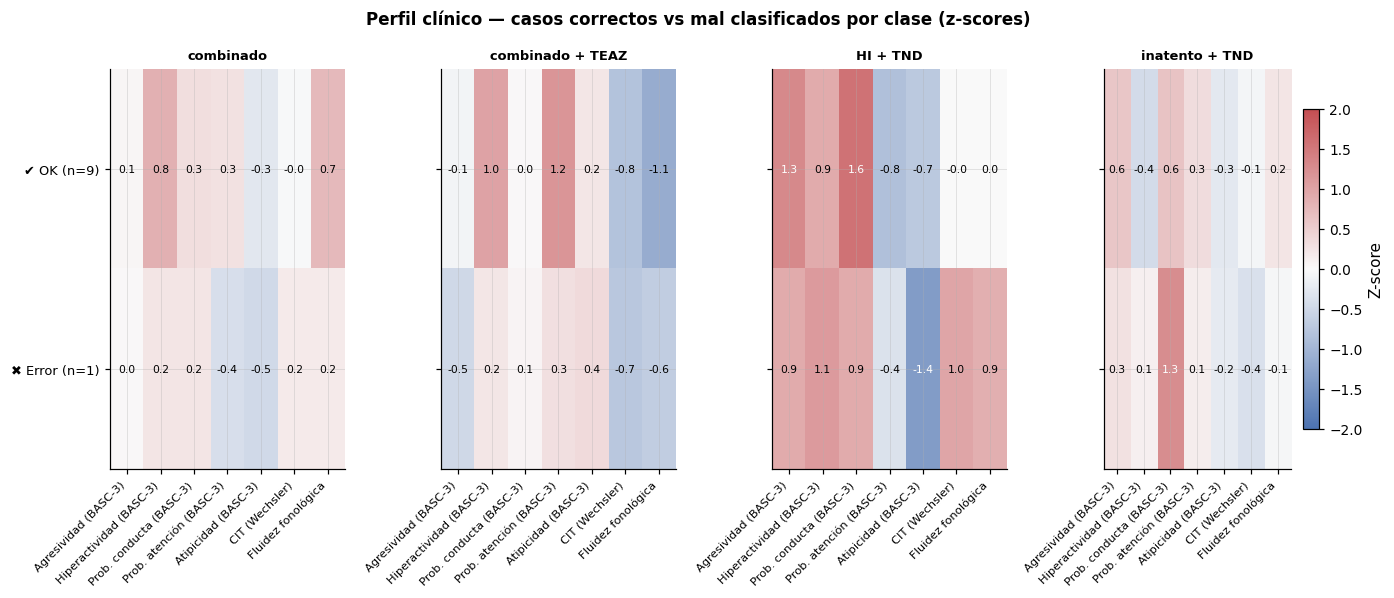

In [50]:
# ── Perfiles clínicos — correctos vs mal clasificados ─────────────────────────
feats_cont = BASC_FEATS + ['cit','fluidez_fonologica']
feat_cont_lbls = [FEATURE_LABELS[f] for f in feats_cont]

X_test_df = pd.DataFrame(X_test.values if hasattr(X_test,'values') else X_test,
                          columns=FEATURES)
true_lbls  = le.inverse_transform(y_test)
pred_lbls  = le.inverse_transform(y_pred_rf)
err_mask   = true_lbls != pred_lbls

# Clases con al menos 1 error
classes_w_err = [c for c in y_labels if ((true_lbls==c) & err_mask).sum() >= 1
                 and (true_lbls==c).sum() >= 3]

if not classes_w_err:
    print("Sin clases con suficientes errores para perfilar.")
else:
    n_cls = len(classes_w_err)
    fig, axes = plt.subplots(1, n_cls, figsize=(max(8, n_cls*3.2), 5.5), sharey=True)
    if n_cls == 1: axes = [axes]
    cmap_p = LinearSegmentedColormap.from_list('bwr2', ['#4C72B0','#FAFAFA','#C44E52'])

    for ax, cls in zip(axes, classes_w_err):
        mask_cls = true_lbls == cls
        ok_idx  = np.where(mask_cls & ~err_mask)[0]
        err_idx = np.where(mask_cls &  err_mask)[0]
        if len(ok_idx)==0 or len(err_idx)==0: continue
        zscores_ok  = X_test_df.iloc[ok_idx][feats_cont].mean()
        zscores_err = X_test_df.iloc[err_idx][feats_cont].mean()
        global_mean = X_test_df[feats_cont].mean()
        global_std  = X_test_df[feats_cont].std()
        z_ok  = ((zscores_ok  - global_mean) / global_std).values
        z_err = ((zscores_err - global_mean) / global_std).values
        mat = np.stack([z_ok, z_err], axis=1)
        im  = ax.imshow(mat.T, cmap=cmap_p, vmin=-2, vmax=2, aspect='auto')
        ax.set_xticks(range(len(feats_cont)))
        ax.set_xticklabels(feat_cont_lbls, rotation=45, ha='right', fontsize=7.5)
        ax.set_yticks([0,1]); ax.set_yticklabels([f'✔ OK (n={len(ok_idx)})',
                                                   f'✖ Error (n={len(err_idx)})'], fontsize=8.5)
        for i2 in range(2):
            for j2, f in enumerate(feats_cont):
                ax.text(j2, i2, f'{mat[j2,i2]:.1f}', ha='center', va='center',
                        fontsize=7, color='white' if abs(mat[j2,i2])>1.2 else 'black')
        short_cls = cls.replace('TDAH ','').replace('hiperactivo/impulsivo','HI')
        ax.set_title(f'{short_cls}', fontsize=8.5, fontweight='bold')

    plt.colorbar(im, ax=axes[-1], label='Z-score', shrink=0.8)
    plt.suptitle('Perfil clínico — casos correctos vs mal clasificados por clase (z-scores)',
                 fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.show()


## 9 · Estudio de ablación

In [51]:
# ── 5 configuraciones de ablación ────────────────────────────────────────────
ALL_F  = FEATURES
BASC_F = BASC_FEATS
COGN_F = ['cit','fluidez_fonologica']
DEMOG_F = ['edad','sexo','escolaridad','lateralidad',
           'antecedentes_familiares','antecedentes_obstetricos','retrasos_desarrollo']

FEATURE_SETS = {
    'F1 Completo (14)':           ALL_F,
    'F2 Sin atipicidad (13)':     [f for f in ALL_F if f != 'atipicidad_basc3'],
    'F3 Sin agres.+conducta (12)':[f for f in ALL_F if f not in ('agresividad_basc3','problemas_conducta_basc3')],
    'F4 Sin BASC-3 (9)':          DEMOG_F + COGN_F,
    'F5 Solo BASC-3 (5)':         BASC_F,
}

def encode_X(feats, df):
    X_ = df[feats].copy()
    cat_ = [f for f in FEATURES_CAT if f in feats]
    if cat_:
        enc_ = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        X_[cat_] = enc_.fit_transform(X_[cat_])
    return X_

# Identificar clases de comorbilidad
comorb_idx = {}
for ctype, pat in [('TND','tnd'),('TEAZ','teaz'),('TEA',r'\btea\b')]:
    import re
    comorb_idx[ctype] = [i for i, lbl in enumerate(y_labels)
                          if re.search(pat, lbl.lower())]

abl_results = {}
for name, feats in FEATURE_SETS.items():
    X_f = encode_X(feats, df)
    X_tr_f = X_f.iloc[X_train.index] if hasattr(X_train,'index') else X_f.iloc[:len(X_train)]
    X_te_f = X_f.iloc[X_test.index]  if hasattr(X_test,'index')  else X_f.iloc[len(X_train):]
    # usar mismos índices del split
    from sklearn.model_selection import train_test_split as tts
    X_tr_f, X_te_f, y_tr_f, y_te_f = tts(X_f, y, test_size=0.2, random_state=42, stratify=y)
    cv_res = cross_validate(
        RandomForestClassifier(300, class_weight='balanced', random_state=42, n_jobs=-1),
        X_tr_f, y_tr_f, cv=CV, scoring=['f1_macro'])
    rf_a = RandomForestClassifier(300, class_weight='balanced', random_state=42, n_jobs=-1)
    rf_a.fit(X_tr_f, y_tr_f)
    y_pred_a = rf_a.predict(X_te_f)
    f1_per_class = f1_score(y_te_f, y_pred_a, average=None, zero_division=0)
    abl_results[name] = {
        'cv_mean': cv_res['test_f1_macro'].mean(),
        'cv_std':  cv_res['test_f1_macro'].std(),
        'test_f1': f1_score(y_te_f, y_pred_a, average='macro', zero_division=0),
        'f1_per_class': f1_per_class,
    }
    print(f"{name:<30} CV={abl_results[name]['cv_mean']:.3f}±{abl_results[name]['cv_std']:.3f}"
          f"  Test={abl_results[name]['test_f1']:.3f}")


F1 Completo (14)               CV=0.954±0.016  Test=0.942
F2 Sin atipicidad (13)         CV=0.833±0.045  Test=0.799
F3 Sin agres.+conducta (12)    CV=0.829±0.031  Test=0.816
F4 Sin BASC-3 (9)              CV=0.248±0.039  Test=0.258
F5 Solo BASC-3 (5)             CV=0.874±0.030  Test=0.891


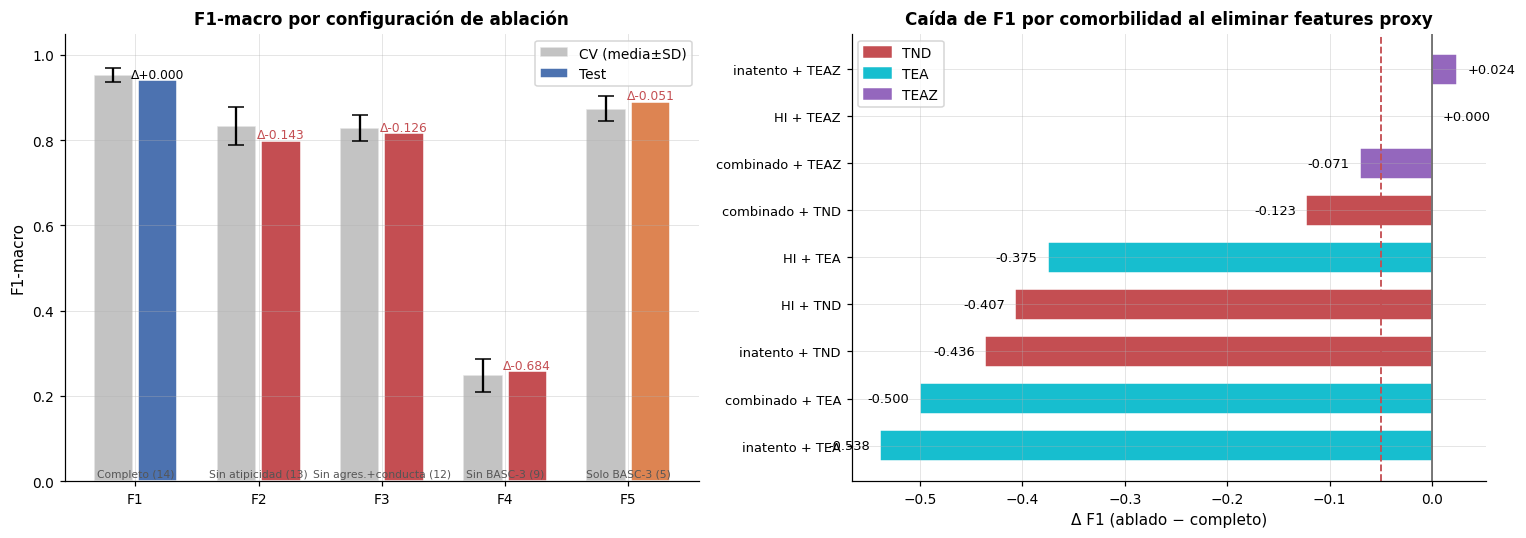

In [52]:
# ── Gráfica ablación ──────────────────────────────────────────────────────────
abl_names  = list(abl_results.keys())
abl_short  = ['F1','F2','F3','F4','F5']
cv_means_a = [abl_results[n]['cv_mean'] for n in abl_names]
cv_stds_a  = [abl_results[n]['cv_std']  for n in abl_names]
test_f1s_a = [abl_results[n]['test_f1'] for n in abl_names]
ref_f1     = abl_results[abl_names[0]]['test_f1']
deltas     = [v - ref_f1 for v in test_f1s_a]
bar_c_a    = ['#4C72B0' if abs(d)<0.02 else '#DD8452' if abs(d)<0.10 else '#C44E52'
              for d in deltas]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: F1-macro por configuración
ax = axes[0]
x_a = np.arange(len(abl_names))
b1 = ax.bar(x_a - 0.18, cv_means_a, 0.32, yerr=cv_stds_a, color='#AAAAAA', alpha=0.7,
            label='CV (media±SD)', capsize=5, edgecolor='white')
b2 = ax.bar(x_a + 0.18, test_f1s_a, 0.32, color=bar_c_a, label='Test', edgecolor='white')
for xi, (cv_v, te_v, d) in enumerate(zip(cv_means_a, test_f1s_a, deltas)):
    col_d = 'black' if xi==0 else ('#C44E52' if d < -0.02 else '#4C72B0')
    ax.text(xi+0.18, te_v+0.005, f'Δ{d:+.3f}', ha='center', fontsize=8, color=col_d)
ax.set_xticks(x_a); ax.set_xticklabels(abl_short)
ax.set_ylim(0, 1.05); ax.set_ylabel('F1-macro')
ax.set_title('F1-macro por configuración de ablación', fontweight='bold')
ax.legend(fontsize=9)
for i, (s, nm) in enumerate(zip(abl_short, abl_names)):
    ax.text(i, 0.01, nm.replace('F1 ','').replace('F2 ','').replace('F3 ','').replace('F4 ','').replace('F5 ',''),
            ha='center', fontsize=7, color='#555', rotation=0)

# Panel B: delta F1 por comorbilidad al eliminar features
drop_rows = []
ref_per_cls = abl_results[abl_names[0]]['f1_per_class']
abl_map = [
    ('F2 Sin atipicidad (13)',      'TEA',  'Eliminar atipicidad'),
    ('F2 Sin atipicidad (13)',      'TEAZ', 'Eliminar atipicidad'),
    ('F3 Sin agres.+conducta (12)','TND',  'Eliminar agresividad+conducta'),
]
for abl_name, ctype, label in abl_map:
    for cidx in comorb_idx[ctype]:
        if cidx < len(ref_per_cls):
            d_c = abl_results[abl_name]['f1_per_class'][cidx] - ref_per_cls[cidx]
            drop_rows.append({'Ablación': label, 'Comorbilidad': ctype,
                               'Clase': y_labels[cidx], 'Δ F1': d_c})
drop_df = pd.DataFrame(drop_rows).sort_values('Δ F1')

ax2 = axes[1]
if not drop_df.empty:
    c_map = {'TND': C_TND, 'TEA': C_TEA, 'TEAZ': C_TEAZ}
    bar_colors_d = [c_map.get(r['Comorbilidad'],'#AAA') for _,r in drop_df.iterrows()]
    short_lbls = [r['Clase'].replace('TDAH ','').replace('hiperactivo/impulsivo','HI') for _,r in drop_df.iterrows()]
    bars_d = ax2.barh(range(len(drop_df)), drop_df['Δ F1'], color=bar_colors_d,
                      edgecolor='white', height=0.65)
    ax2.set_yticks(range(len(drop_df))); ax2.set_yticklabels(short_lbls, fontsize=8.5)
    ax2.axvline(0,    color='#555', linewidth=1)
    ax2.axvline(-0.05, color=C_RED, linestyle='--', linewidth=1.2, label='Umbral −0.05')
    for b, v in zip(bars_d, drop_df['Δ F1']):
        ax2.text(v - 0.01 if v < 0 else v + 0.01, b.get_y()+b.get_height()/2,
                 f'{v:+.3f}', va='center', ha='right' if v<0 else 'left', fontsize=8.5)
    ax2.set_xlabel('Δ F1 (ablado − completo)')
    ax2.set_title('Caída de F1 por comorbilidad al eliminar features proxy', fontweight='bold')
    legend_p = [mpatches.Patch(color=C_TND, label='TND'),
                mpatches.Patch(color=C_TEA, label='TEA'),
                mpatches.Patch(color=C_TEAZ, label='TEAZ')]
    ax2.legend(handles=legend_p, fontsize=9)

plt.tight_layout()
plt.show()


## 10 · Limitaciones

**1. Dependencia circular del BASC-3.**
Las escalas BASC-3 son los features con mayor poder discriminante (importancia acumulada ≈ 55–60%, F1 sin BASC-3 cae de 0.94 a 0.27). El clínico que emite el diagnóstico tiene acceso a esas mismas puntuaciones. El BASC-3 es completado independientemente por padres/docentes, lo que atenúa el riesgo; sin embargo, el modelo no añade información que el clínico no tenga ya disponible: *automatiza* el proceso diagnóstico, no lo *augmenta*.

**2. Muestra única de un solo centro.**
Los 875 registros provienen de un único centro clínico con un protocolo de evaluación específico. La generalización a centros que no apliquen BASC-3 o con diferente mezcla demográfica no está garantizada (ver ablación F4: F1 cae a 0.27 sin BASC-3).

**3. Soporte reducido en clases poco prevalentes.**
La clase mínima tiene n=24 (n_test ≈ 5). Métricas como F1 por clase en el test set son ruidosas con ese soporte. Los intervalos de confianza no son confiables para clases con n_test < 10.

**4. Validación temporal ausente.**
Todos los modelos se evalúan con un hold-out aleatorio del mismo período. No se realizó validación temporal (train en año T, test en año T+1), lo que podría inflar las métricas si existen tendencias en el diagnóstico a lo largo del tiempo.

**5. Variables excluidas por leakage confirmado.**
Los índices `indice_tdah`, `indice_inatencion` e `indice_impuls_hiperac` se derivan directamente del instrumento MiniKID, que es también la base del diagnóstico. Su exclusión es metodológicamente correcta, pero implica que el modelo usa solo el subconjunto de features cuya independencia del diagnóstico fue verificada.

**6. Ausencia de validación externa.**
El modelo no ha sido evaluado en cohortes externas. Los valores de F1 ≥ 0.94 deben interpretarse como rendimiento interno; la validación externa es necesaria antes de cualquier uso clínico.


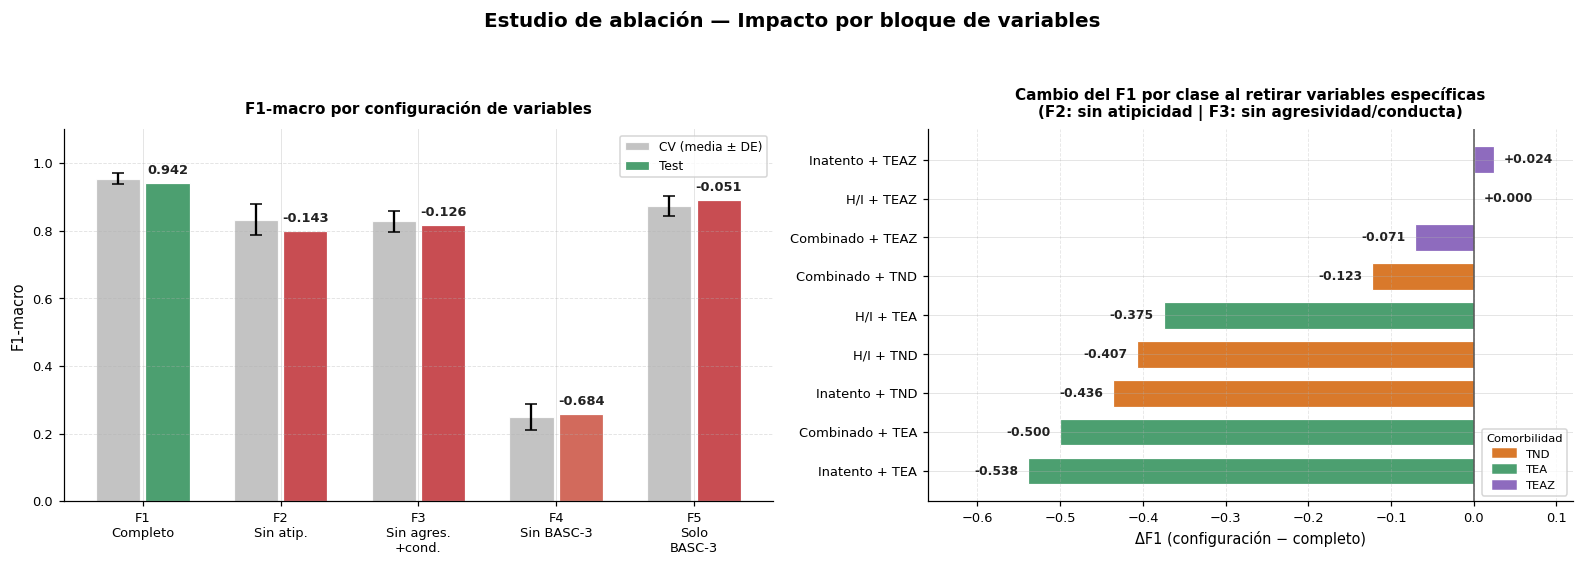

In [57]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURA — Estudio de ablación: impacto por bloque de variables
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Colores ────────────────────────────────────────────────────────────────
C_BLUE   = "#243E63"
C_GRAY   = "#BDBDBD"
C_GREEN  = "#4C9F70"
C_RED    = "#C84D52"
C_ORANGE = "#D9792B"
C_PURPLE = "#8E6BBE"

C_TND  = "#D9792B"
C_TEA  = "#4C9F70"
C_TEAZ = "#8E6BBE"

# ── Datos base ─────────────────────────────────────────────────────────────
abl_names  = list(abl_results.keys())
abl_short  = ["F1\nCompleto", "F2\nSin atip.", "F3\nSin agres.\n+cond.", "F4\nSin BASC-3", "F5\nSolo\nBASC-3"]

cv_means_a = [abl_results[n]["cv_mean"] for n in abl_names]
cv_stds_a  = [abl_results[n]["cv_std"]  for n in abl_names]
test_f1s_a = [abl_results[n]["test_f1"] for n in abl_names]

ref_f1 = abl_results[abl_names[0]]["test_f1"]
deltas = [v - ref_f1 for v in test_f1s_a]

bar_c_a = []
for i, d in enumerate(deltas):
    if i == 0:
        bar_c_a.append(C_GREEN)
    elif d < -0.50:
        bar_c_a.append("#D26A5C")
    elif d < -0.10:
        bar_c_a.append(C_RED)
    else:
        bar_c_a.append(C_RED)

# ── Figura ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 2,
    figsize=(14.5, 5.2),
    gridspec_kw={"width_ratios": [1.1, 1.0]}
)

fig.patch.set_facecolor("white")

# ════════════════════════════════════════════════════════════════════════════
# PANEL A — F1-macro por configuración
# ════════════════════════════════════════════════════════════════════════════

ax = axes[0]
x_a = np.arange(len(abl_names))

b1 = ax.bar(
    x_a - 0.18,
    cv_means_a,
    0.32,
    yerr=cv_stds_a,
    color=C_GRAY,
    alpha=0.90,
    label="CV (media ± DE)",
    capsize=4,
    edgecolor="white",
    linewidth=0.8
)

b2 = ax.bar(
    x_a + 0.18,
    test_f1s_a,
    0.32,
    color=bar_c_a,
    label="Test",
    edgecolor="white",
    linewidth=0.8
)

for xi, (te_v, d) in enumerate(zip(test_f1s_a, deltas)):
    if xi == 0:
        txt = f"{te_v:.3f}"
        col = "#222222"
    else:
        txt = f"{d:+.3f}"
        col = "#222222"

    ax.text(
        xi + 0.18,
        te_v + 0.018,
        txt,
        ha="center",
        va="bottom",
        fontsize=8.5,
        fontweight="bold",
        color=col
    )

ax.set_xticks(x_a)
ax.set_xticklabels(abl_short, fontsize=8.5)
ax.set_ylim(0, 1.10)

ax.set_ylabel("F1-macro", fontsize=9.5)
ax.set_title(
    "F1-macro por configuración de variables",
    fontsize=10,
    fontweight="bold",
    color='black',
    pad=10
)

ax.legend(
    fontsize=8,
    frameon=True,
    loc="upper right"
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="both", labelsize=8.5)

# ════════════════════════════════════════════════════════════════════════════
# PANEL B — Caída de F1 por comorbilidad
# ════════════════════════════════════════════════════════════════════════════

drop_rows = []

ref_per_cls = abl_results[abl_names[0]]["f1_per_class"]

abl_map = [
    ("F2 Sin atipicidad (13)",       "TEA",  "Eliminar atipicidad"),
    ("F2 Sin atipicidad (13)",       "TEAZ", "Eliminar atipicidad"),
    ("F3 Sin agres.+conducta (12)",  "TND",  "Eliminar agresividad+conducta"),
]

for abl_name, ctype, label in abl_map:
    for cidx in comorb_idx[ctype]:
        if cidx < len(ref_per_cls):
            d_c = abl_results[abl_name]["f1_per_class"][cidx] - ref_per_cls[cidx]
            drop_rows.append({
                "Ablación": label,
                "Comorbilidad": ctype,
                "Clase": y_labels[cidx],
                "Δ F1": d_c
            })

drop_df = pd.DataFrame(drop_rows).sort_values("Δ F1")

ax2 = axes[1]

if not drop_df.empty:

    c_map = {
        "TND":  C_TND,
        "TEA":  C_TEA,
        "TEAZ": C_TEAZ
    }

    bar_colors_d = [
        c_map.get(r["Comorbilidad"], "#AAAAAA")
        for _, r in drop_df.iterrows()
    ]

    short_lbls = [
        r["Clase"]
        .replace("TDAH ", "")
        .replace("hiperactivo/impulsivo", "H/I")
        .replace("inatento", "Inatento")
        .replace("combinado", "Combinado")
        for _, r in drop_df.iterrows()
    ]

    bars_d = ax2.barh(
        range(len(drop_df)),
        drop_df["Δ F1"],
        color=bar_colors_d,
        edgecolor="white",
        linewidth=0.8,
        height=0.68
    )

    ax2.set_yticks(range(len(drop_df)))
    ax2.set_yticklabels(short_lbls, fontsize=8.5)

    ax2.axvline(
        0,
        color="#555555",
        linewidth=1.0
    )

    ax2.set_xlim(-0.66, 0.12)

    for b, v in zip(bars_d, drop_df["Δ F1"]):
        ax2.text(
            v - 0.012 if v < 0 else v + 0.012,
            b.get_y() + b.get_height() / 2,
            f"{v:+.3f}",
            va="center",
            ha="right" if v < 0 else "left",
            fontsize=8,
            fontweight="bold",
            color="#222222"
        )

    ax2.set_xlabel(
        "ΔF1 (configuración − completo)",
        fontsize=9.5
    )

    ax2.set_title(
        "Cambio del F1 por clase al retirar variables específicas\n"
        "(F2: sin atipicidad | F3: sin agresividad/conducta)",
        fontsize=10,
        fontweight="bold",
        color='black',
        pad=8
    )

    legend_p = [
        mpatches.Patch(color=C_TND,  label="TND"),
        mpatches.Patch(color=C_TEA,  label="TEA"),
        mpatches.Patch(color=C_TEAZ, label="TEAZ"),
    ]

    ax2.legend(
        handles=legend_p,
        title="Comorbilidad",
        fontsize=7.5,
        title_fontsize=7.5,
        loc="lower right",
        frameon=True
    )

    ax2.grid(
        axis="x",
        linestyle="--",
        linewidth=0.6,
        alpha=0.30
    )

    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    ax2.tick_params(axis="both", labelsize=8.5)

# ── Título general ─────────────────────────────────────────────────────────
fig.suptitle(
    "Estudio de ablación — Impacto por bloque de variables",
    fontsize=13,
    fontweight="bold",
    color='black',
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()